# Pipelines
### `! git clone https://github.com/ds4e/pipelines`

## Introduction
- By this point, we have used several families of models: $k$-NN, linear models, trees, ensembles, PCA/clustering, and classification models
- The mechanics differ, but the work around the model is often the same:
    1. decide which columns are features and which column is the target
    2. split the sample
    3. impute missing values
    4. scale numeric variables when the model cares about scale
    5. encode categorical variables
    6. fit, predict, evaluate, and tune
- A **pipeline** is a way to turn that whole workflow into one object that behaves like a model
- This is not just tidier code: It helps prevent subtle mistakes in model evaluation

## Road Map
1. Why preprocessing can leak information
2. A first `Pipeline`
3. `ColumnTransformer` for mixed numeric and categorical data
4. Comparing and tuning entire workflows
5. Classification pipelines
6. A practical recipe

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, KFold, cross_validate, GridSearchCV
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.base import clone

from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 80)

# 1. The Problem Pipelines Solve

## Preprocessing Learns from Data
- Some transformations are just algebra on one row at a time: creating `age_squared = age**2`, taking a log, making an interaction term
- Other transformations learn something from a whole column:
    - a median imputer learns the training median
    - a scaler learns the training mean, standard deviation, median, or IQR
    - one-hot encoding learns which categories exist
- If these transformations are fit on the full dataset before the train-test split, information from the test set quietly leaks into training
- A pipeline keeps the rule simple: **fit every learned transformation only on the training data**

## The `fit` and `predict`/`transform` Steps
Almost every preprocessing object in scikit-learn has two phases:

- `.fit`: pick model parameters on training data
- `.predict` or `.transform`: apply the model to new data

A pipeline integrates upwards, pulling the data cleaning and preprocessing into the object you're building.

In [2]:
airbnb = pd.read_csv("./data/Q1_clean.csv")
airbnb = airbnb.rename(columns=str.strip) # Drop whitespace
airbnb.head()

,Price,Review Scores Rating,Neighbourhood,Property Type,Room Type
0,549,96.0,Manhattan,Apartment,Private room
1,149,100.0,Brooklyn,Apartment,Entire home/apt
2,250,100.0,Manhattan,Apartment,Entire home/apt
3,90,94.0,Brooklyn,Apartment,Private room
4,270,90.0,Manhattan,Apartment,Entire home/apt


In [3]:
airbnb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22153 entries, 0 to 22152
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Price                 22153 non-null  int64  
 1   Review Scores Rating  22153 non-null  float64
 2   Neighbourhood         22153 non-null  object 
 3   Property Type         22153 non-null  object 
 4   Room Type             22153 non-null  object 
dtypes: float64(1), int64(1), object(3)
memory usage: 865.5+ KB


## A Small Leakage Example
We will model `log_price`, not raw price, because nightly prices have a long right tail. That is a feature-engineering choice from earlier lessons: make the outcome more stable before modeling it.

In [4]:
airbnb = airbnb.query("20 <= Price <= 1000").copy()
airbnb["log_price"] = np.log1p(airbnb["Price"])

features = ["Review Scores Rating", "Neighbourhood", "Property Type", "Room Type"]
target = "log_price"

X = airbnb[features].copy()
y = airbnb[target].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, 
                test_size=0.2, random_state=100)

print(X_train.shape, X_test.shape)

(17691, 4) (4423, 4)


In [5]:
scaler = StandardScaler()

# Correct: learn the scaling rule on the training set only.
train_scaled = scaler.fit_transform(X_train[["Review Scores Rating"]])
test_scaled = scaler.transform(X_test[["Review Scores Rating"]])

print("Training mean learned by scaler:", scaler.mean_[0].round(3))
print("Mean of scaled training column:", train_scaled.mean().round(3))
print("Mean of scaled test column:", test_scaled.mean().round(3))

Training mean learned by scaler: 92.017
Mean of scaled training column: -0.0
Mean of scaled test column: -0.017


## What Just Happened?
- The scaled training column has mean `0` because the scaler learned its center from the training set
- The scaled test column does **not** have to have mean `0`
- That is the point: the test set should act like new data that arrives later
- If we had fit the scaler on the full dataset, the test set would help define the transformation used to evaluate itself

# 2. A First Pipeline

## Pipeline as a Chain
A pipeline is an ordered list of named steps:

```python
pipe = Pipeline(steps=[
    ("step_name", transformer_or_model()),
    ("model", estimator()),
])
```

All steps except the last usually transform data. The last step is usually the model.

In [6]:
numeric_knn = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", KNeighborsRegressor(n_neighbors=35)),
    ]
)

numeric_knn

,steps,"[('imputer', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,copy,True


In [7]:
one_feature = ["Review Scores Rating"]

numeric_knn.fit(X_train[one_feature], y_train)
y_hat = numeric_knn.predict(X_test[one_feature])

pd.Series({
    "MAE": mean_absolute_error(y_test, y_hat),
    "RMSE": mean_squared_error(y_test, y_hat) ** 0.5,
    "R2": r2_score(y_test, y_hat),
}).round(3)

MAE     0.464
RMSE    0.579
R2     -0.007
dtype: float64

## Why This Is Nice
- `numeric_knn.fit(...)` fits the imputer, then the scaler, then the $k$-NN model
- `numeric_knn.predict(...)` applies the same imputation and scaling recipe before predicting
- The test data never gets to teach the imputer or scaler anything
- The workflow itself now has the same interface as a model: `.fit()`, `.predict()`, `.score()`

In [8]:
numeric_knn.named_steps # What is in this thing?

{'imputer': SimpleImputer(strategy='median'),
 'scaler': StandardScaler(),
 'model': KNeighborsRegressor(n_neighbors=35)}

## Exercise
- Change `n_neighbors` to a very small value like `3`
- Change it to a larger value like `100`
- Which one does better on RMSE?
- How does this connect to the bias-variance trade-off?

# 3. ColumnTransformer

## Different Features/Variables Need Different Treatment
Our Airbnb example has one numeric feature and several categorical features.

- Numeric: impute missing values, then scale
- Categorical: impute missing labels, then one-hot encode

`ColumnTransformer` lets us apply different pipelines to different columns, then glue the transformed features back together.

![Pipelining Process](./data/pipelining.png)

In [9]:
# Our first big pipeline

numeric_features = ["Review Scores Rating"]
categorical_features = ["Neighbourhood", "Property Type", "Room Type"]

numeric_preprocess = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", RobustScaler()),
    ]
)

categorical_preprocess = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                min_frequency=50,
                sparse_output=False,
            ),
        ),
    ]
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_preprocess, numeric_features),
        ("cat", categorical_preprocess, categorical_features),
    ],
    verbose_feature_names_out=False,
)

preprocess

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


## Two Details Worth Remembering
- `handle_unknown="ignore"` means the pipeline will not crash if the test set contains a category that did not appear in training
- `min_frequency=50` groups rare categories together, which prevents the feature space from exploding into many tiny one-hot columns

Those are small choices, but they are exactly the kind of choices that make a workflow more robust.

In [10]:
ridge_pipe = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", Ridge(alpha=10.0)),
    ]
)

ridge_pipe.fit(X_train, y_train)
y_hat_ridge = ridge_pipe.predict(X_test)

pd.Series({
    "MAE": mean_absolute_error(y_test, y_hat_ridge),
    "RMSE": mean_squared_error(y_test, y_hat_ridge) ** 0.5,
    "R2": r2_score(y_test, y_hat_ridge),
}).round(3)

MAE     0.295
RMSE    0.390
R2      0.544
dtype: float64

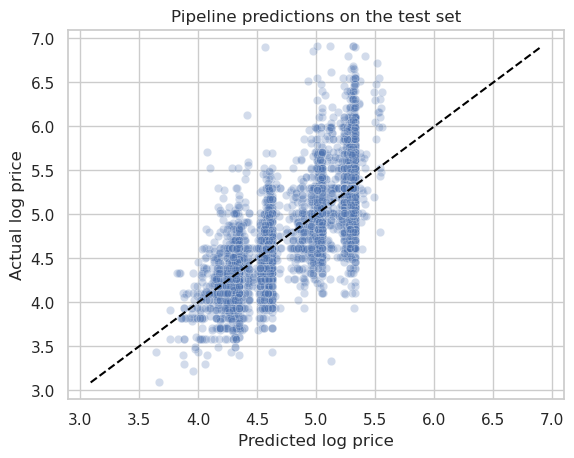

In [11]:
plot_df = pd.DataFrame({"actual": y_test, "predicted": y_hat_ridge})

sns.scatterplot(data=plot_df, x="predicted", y="actual", alpha=0.25)
plt.plot([plot_df.min().min(), plot_df.max().max()], [plot_df.min().min(), plot_df.max().max()], color="black", linestyle="--")
plt.xlabel("Predicted log price")
plt.ylabel("Actual log price")
plt.title("Pipeline predictions on the test set")
plt.show()

## Looking Inside the Pipeline
The fitted pipeline still lets us inspect its pieces.

This is useful when we want coefficients, transformed feature names, feature importances, or a diagnostic plot.

In [12]:
feature_names = ridge_pipe.named_steps["preprocess"].get_feature_names_out()
coefs = pd.Series(ridge_pipe.named_steps["model"].coef_, index=feature_names)

coefs.reindex(coefs.abs().sort_values(ascending=False).index).head(12).round(3)

Room Type_Entire home/apt        0.576
Room Type_Shared room           -0.441
Neighbourhood_Manhattan          0.358
Neighbourhood_Bronx             -0.194
Neighbourhood_Staten Island     -0.165
Property Type_Loft               0.134
Room Type_Private room          -0.134
Property Type_Apartment         -0.090
Neighbourhood_Brooklyn           0.079
Neighbourhood_Queens            -0.078
Review Scores Rating             0.053
Property Type_Bed & Breakfast   -0.022
dtype: float64

## Pipeline Rule of Thumb
When a step learns from the data, put it **inside** the pipeline.

Good pipeline steps:
- imputation
- scaling
- one-hot encoding
- polynomial expansion
- PCA
- feature selection
- the final model

Things that usually happen before the pipeline:
- reading the data file
- fixing column names
- choosing the target variable
- making clear row filters that would be available before modeling

# 4. Comparing Workflows

## Models Are Not the Only Thing We Compare
A fair comparison should compare entire workflows.

For example:
- $k$-NN really needs scaled numeric variables
- linear models often benefit from carefully encoded categoricals and regularization
- trees do not care much about scaling, but they still need categorical variables represented numerically

Pipelines make the whole workflow explicit.

In [13]:
def regression_scores(y_true, y_pred):
    return pd.Series({"MAE": mean_absolute_error(y_true, y_pred),
            "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
            "R2": r2_score(y_true, y_pred)})

models = {
    "ridge": Ridge(alpha=10.0),
    "knn": KNeighborsRegressor(n_neighbors=35),
    "tree": DecisionTreeRegressor(max_depth=8, random_state=100),}

rows = []
fitted_pipes = {}

for name, model in models.items():
    pipe = Pipeline(
        steps=[
            ("preprocess", clone(preprocess)),
            ("model", model),
        ]
    )
    pipe.fit(X_train, y_train)
    fitted_pipes[name] = pipe
    scores = regression_scores(y_test, pipe.predict(X_test))
    rows.append(scores.rename(name))

model_compare = pd.DataFrame(rows).round(3)
model_compare

,MAE,RMSE,R2
ridge,0.295,0.390,0.544
knn,0.300,0.394,0.535
tree,0.294,0.390,0.544


## Cross Validation with Pipelines
The same pipeline can go directly into cross-validation.

This is the payoff: each fold learns its own imputer, scaler, one-hot encoder, and model using only that fold's training chunk.

In [14]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

cv_results = cross_validate(
    ridge_pipe,
    X,
    y,
    cv=kfold,
    scoring={"mse": "neg_mean_squared_error", "r2": "r2"},
    return_train_score=True,
)

cv_table = pd.DataFrame(
    {
        "fold": np.arange(1, kfold.get_n_splits() + 1),
        "train_RMSE": np.sqrt(-cv_results["train_mse"]),
        "test_RMSE": np.sqrt(-cv_results["test_mse"]),
        "test_R2": cv_results["test_r2"],
    }
)

cv_table.round(3)

,fold,train_RMSE,test_RMSE,test_R2
0,1,0.382,0.391,0.538
1,2,0.385,0.380,0.546
2,3,0.383,0.389,0.545
3,4,0.386,0.379,0.553
4,5,0.384,0.383,0.553


In [15]:
cv_table.drop(columns="fold").agg(["mean", "std"]).round(3)

,train_RMSE,test_RMSE,test_R2
mean,0.384,0.384,0.547
std,0.001,0.006,0.006


## Tuning a Pipeline
Pipeline steps have names. Parameters inside those steps are reached with double underscores:

```python
model__alpha
preprocess__cat__onehot__min_frequency
```

That reads as: go into the pipeline step called `preprocess`, then into the transformer called `cat`, then into the step called `onehot`, then change `min_frequency`.

In [16]:
param_grid = {
    "model__alpha": [0.1, 1.0, 10.0, 100.0],
    "preprocess__cat__onehot__min_frequency": [10, 50, 200],
}

search = GridSearchCV(
    ridge_pipe,
    param_grid=param_grid,
    cv=kfold,
    scoring="neg_mean_squared_error",
)

search.fit(X_train, y_train)

print("Best parameters:", search.best_params_)
print("Best cross-validated RMSE:", np.sqrt(-search.best_score_))

Best parameters: {'model__alpha': 1.0, 'preprocess__cat__onehot__min_frequency': 200}
Best cross-validated RMSE: 0.38303717984705277


In [17]:
best_pipe = search.best_estimator_
y_hat_best = best_pipe.predict(X_test)

regression_scores(y_test, y_hat_best)

MAE     0.294697
RMSE    0.389641
R2      0.544695
dtype: float64

## Cross Validation versus Train/Test Split
- Use cross-validation to select hyperparameters, then use the test set once at the end.
- The test set is not a place to shop around for the model you like: It is a final check of how the chosen workflow behaves on held-out data.

# 5. Classification Pipelines

## Same Idea, Different Final Model
For classification, the pipeline structure is exactly the same. The final estimator changes, and the evaluation metrics change.

We will revisit the diabetes data from the model evaluation and classifier evaluation lessons.

In [18]:
diabetes = pd.read_csv("./data/diabetes-dataset.csv")

y_cls = diabetes["Outcome"]
X_cls = diabetes.drop(columns="Outcome")

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls,
    y_cls,
    test_size=0.2,
    random_state=100,
    stratify=y_cls,
)

X_train_cls.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
111,8,155,62,26,495,34.0,0.543,46
1449,0,107,62,30,74,36.6,0.757,25
345,8,126,88,36,108,38.5,0.349,49
1046,0,73,0,0,0,21.1,0.342,25
187,1,128,98,41,58,32.0,1.321,33


In [19]:
diabetes["Outcome"].value_counts(normalize=True).rename("share")

Outcome
0    0.658
1    0.342
Name: share, dtype: float64

## A Numeric Preprocessor
These data are all numeric, so we do not need a `ColumnTransformer`. A simple numeric pipeline is enough.

One subtlety: values like `0` for glucose or blood pressure probably mean missing in this dataset. We will replace those impossible zeros with `NaN` for the variables where zero is not medically meaningful.

In [20]:
zero_as_missing = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

X_cls = diabetes.drop(columns="Outcome").copy()
X_cls[zero_as_missing] = X_cls[zero_as_missing].replace(0, np.nan)
y_cls = diabetes["Outcome"]

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls,
    y_cls,
    test_size=0.2,
    random_state=100,
    stratify=y_cls)

classification_preprocess = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

In [21]:
classifiers = {
    "logit": LogisticRegression(max_iter=2000),
    "knn": KNeighborsClassifier(n_neighbors=35),
    "tree": DecisionTreeClassifier(max_depth=5, random_state=42),
}

classification_rows = []
classification_pipes = {}

for name, model in classifiers.items():
    pipe = Pipeline(
        steps=[
            ("preprocess", clone(classification_preprocess)),
            ("model", model),
        ]
    )
    pipe.fit(X_train_cls, y_train_cls)
    classification_pipes[name] = pipe
    y_pred = pipe.predict(X_test_cls)
    y_score = pipe.predict_proba(X_test_cls)[:, 1]
    classification_rows.append(
        {
            "model": name,
            "accuracy": accuracy_score(y_test_cls, y_pred),
            "F1": f1_score(y_test_cls, y_pred),
            "AUC": roc_auc_score(y_test_cls, y_score),
        }
    )

classification_compare = pd.DataFrame(classification_rows).set_index("model")
classification_compare

,accuracy,F1,AUC
model,,,
logit,0.7600,0.609756,0.834087
knn,0.7475,0.584362,0.849976
tree,0.7950,0.646552,0.851336


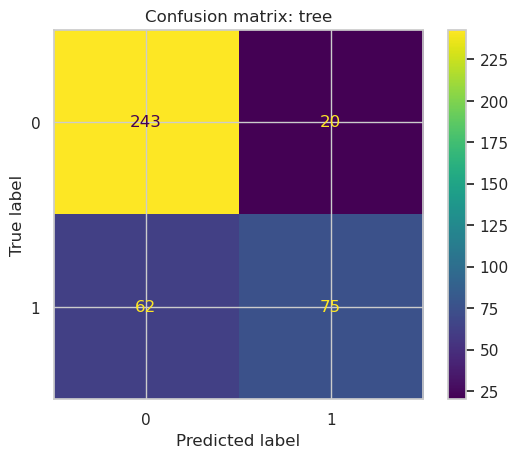

In [22]:
best_classifier_name = classification_compare["AUC"].idxmax()
best_classifier = classification_pipes[best_classifier_name]

y_pred = best_classifier.predict(X_test_cls)
cm = confusion_matrix(y_test_cls, y_pred)

ConfusionMatrixDisplay(cm, display_labels=best_classifier.classes_).plot()
plt.title(f"Confusion matrix: {best_classifier_name}")
plt.show()

## Model-Specific Preprocessing
The previous example used the same preprocessing for every classifier to keep the comparison simple.

In practice, you can make model-specific pipelines:
- $k$-NN: impute and scale
- logistic regression: impute, scale, maybe polynomial features or regularization
- trees and random forests: impute, encode categoricals, usually no scaling needed

The point is not that every model needs the same preprocessing. The point is that each model's preprocessing should be stored with the model that needs it.

# 6. Practical Recipe

## A Pipeline Checklist
1. Load the data and do obvious row/column fixes in pandas
2. Choose `y` and `X`
3. Split into training and testing data
4. List numeric, categorical, text, date, or other feature groups
5. Build one small preprocessing pipeline for each group
6. Combine them with `ColumnTransformer`
7. Attach the model with `Pipeline`
8. Evaluate the whole pipeline with cross-validation
9. Tune the whole pipeline with `GridSearchCV`
10. Use the test set once for the final check

## Common Mistakes
- Scaling or imputing the whole dataset before the train-test split
- One-hot encoding train and test separately, which can create mismatched columns
- Forgetting `handle_unknown="ignore"` for categorical variables
- Comparing a carefully tuned model to an untuned model and calling it a model comparison
- Tuning on the test set until the test score looks good
- Losing track of which preprocessing recipe produced which model

## Exercises
1. Add `PolynomialFeatures(degree=2, include_bias=False)` to the numeric Airbnb preprocessing pipeline before the ridge model. Does it improve cross-validated RMSE?
2. Tune the $k$-NN regressor with `model__n_neighbors` in `[5, 15, 35, 75, 125]`. Does the selected value match your intuition from the bias-variance trade-off?
3. For the diabetes classifier, compare logistic regression with and without polynomial features. Which has better AUC? Which has better calibration?
4. Build a pipeline for the Brazil default dataset using numeric and categorical feature groups. Start small: pick 5-10 columns before trying all 54.

## Conclusion
- A pipeline turns preprocessing plus modeling into one estimator
- This makes code shorter, but the deeper value is honest evaluation
- `Pipeline` handles sequential steps
- `ColumnTransformer` handles different kinds of columns
- Cross-validation and grid search work directly on pipelines
- The habits are the same for regression and classification: keep the recipe with the model, and fit the recipe only on training data